In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets
tf.keras.utils.set_random_seed(0)

In [2]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0]
# 1 => [0 1 0]
# 2 => [0 0 1]

In [3]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]


In [4]:
model = keras.Sequential(
  [
    layers.Dense(3, activation="sigmoid", name="layer1", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer2"),
  ]
)

model.summary()

C:\Users\MOISES INFORMATICA\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
y = model(X)
print(y[149])

tf.Tensor([0.49709976 0.5404058  0.29409492], shape=(3,), dtype=float32)


In [6]:
optimizer=tf.keras.optimizers.SGD(learning_rate=0.03)
loss=tf.keras.losses.MeanSquaredError()

model.compile(optimizer, loss)
history = model.fit(X, Y, epochs=500, verbose=0)

Pérdida final original: 0.18451
Exactitud original: 0.6667


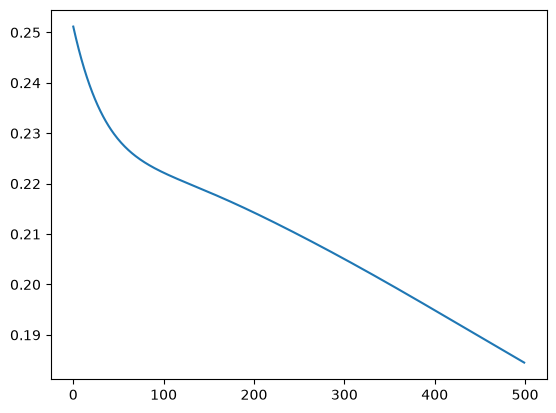

In [7]:
print('Pérdida final original:', round(history.history['loss'][-1], 6))
original_prediction = np.argmax(model.predict(X, verbose=0), axis=1)
print('Exactitud original:', round(np.mean(original_prediction == target), 4))
plt.plot(history.history['loss'])
plt.show()

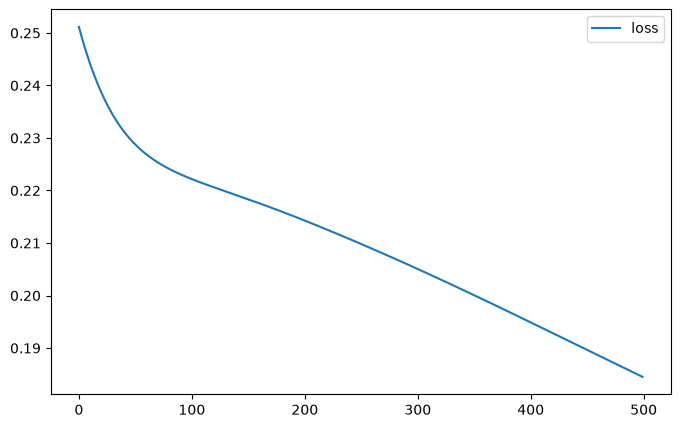

In [8]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

In [9]:
model.predict(np.array([[3,3,1,1]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


array([[0.44908646, 0.3330301 , 0.35677105]], dtype=float32)

## Red profunda: 4 x 3 x 3 x 3 x 3

Se agregan dos capas ocultas y se conservan la activación sigmoide, MSE, SGD
con 0.03 y 500 épocas.

In [10]:
tf.keras.utils.set_random_seed(0)

deep_model = keras.Sequential([
    keras.Input(shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer1"),
    layers.Dense(3, activation="sigmoid", name="layer2"),
    layers.Dense(3, activation="sigmoid", name="layer3"),
    layers.Dense(3, activation="sigmoid", name="layer4"),
])

deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

Pérdida final profunda: 0.222361
Exactitud profunda: 0.3333


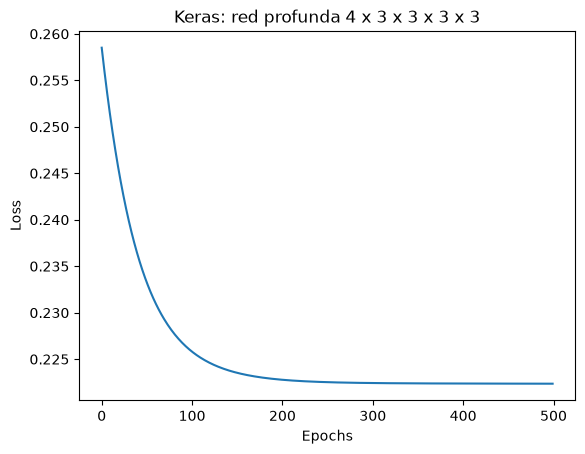

In [11]:
deep_optimizer = tf.keras.optimizers.SGD(learning_rate=0.03)
deep_model.compile(optimizer=deep_optimizer, loss=tf.keras.losses.MeanSquaredError())
deep_history = deep_model.fit(X, Y, epochs=500, verbose=0)

deep_prediction = np.argmax(deep_model.predict(X, verbose=0), axis=1)
deep_accuracy = np.mean(deep_prediction == target)
print('Pérdida final profunda:', round(deep_history.history['loss'][-1], 6))
print('Exactitud profunda:', round(deep_accuracy, 4))

plt.plot(deep_history.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Keras: red profunda 4 x 3 x 3 x 3 x 3')
plt.show()